# Medical Appointment No-Show Prediction

**Dataset**: KaggleV2-May-2016.csv (~110 527 rows)

**Goal**: Predict whether patient will miss appointment (`target = 1` = No-show)

This version:
• uses native categorical support in XGBoost
• groups rare neighbourhoods → no "unseen category" error
• includes several EDA plots
• uses manual DMatrix + xgb.train (stable approach)

In [7]:
# !/usr/bin/env python3
# This code is part of a machine learning pipeline that uses XGBoost for classification tasks. It includes data preprocessing, model training, and evaluation steps. The necessary libraries are imported, and the XGBoost version is printed for reference.
# The code is structured to handle data manipulation with pandas, visualization with seaborn and matplotlib, and machine learning tasks with scikit-learn and XGBoost.  
# Note: The actual data loading, preprocessing, model training, and evaluation steps are not included in this snippet and would need to be implemented separately.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split    
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report 
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

pd.set_option('display.max_columns', 50) # set the maximum number of columns to display when printing a DataFrame
sns.set(style="whitegrid")               # set the style of seaborn plots to "whitegrid", which adds a grid to the background of the plots for better readability.

%matplotlib inline                       
# %matplotlib inline is a magic command in Jupyter notebooks that allows for the display of matplotlib plots directly within the notebook.  


print("XGBoost version:", xgb.__version__) # Print the version of the XGBoost library being used, which can be helpful for debugging and ensuring compatibility with other libraries.

XGBoost version: 3.2.0


## 1. Load data

In [8]:
df = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])

print('Shape:', df.shape)
print('\nNo-show rate:')
print(df['No-show'].value_counts(normalize=True).round(4))

Shape: (110527, 14)

No-show rate:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64


## 2. Cleaning & feature engineering

In [9]:
df = df.rename(columns={
    'PatientId': 'patient_id', 'AppointmentID': 'appointment_id',
    'Gender': 'gender', 'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day', 'Age': 'age',
    'Neighbourhood': 'neighborhood', 'Scholarship': 'scholarship',
    'Hipertension': 'hypertension', 'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism', 'Handcap': 'handicap',
    'SMS_received': 'sms_received', 'No-show': 'no_show'
})

df['target'] = df['no_show'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['no_show'])

df['wait_days'] = (df['appointment_day'].dt.normalize() - df['scheduled_day'].dt.normalize()).dt.days.clip(lower=0)
df['scheduled_hour'] = df['scheduled_day'].dt.hour
df['appointment_dow'] = df['appointment_day'].dt.day_name()
df['appointment_is_weekend'] = df['appointment_day'].dt.weekday >= 5
df['same_day'] = (df['wait_days'] == 0).astype(int)

df = df[(df['age'] >= 0) & (df['age'] <= 115)]
df['handicap_binary'] = (df['handicap'] > 0).astype(int)

# Patient history features
df = df.sort_values(['patient_id', 'scheduled_day'])
df['prev_appointments'] = df.groupby('patient_id').cumcount()
df['cum_no_shows'] = df.groupby('patient_id')['target'].cumsum().shift(1).fillna(0)
df['prev_no_show_rate'] = np.where(df['prev_appointments'] > 0, df['cum_no_shows'] / df['prev_appointments'], 0.0)
df['days_since_last'] = df.groupby('patient_id')['appointment_day'].diff().dt.days.fillna(999)

print('Cleaned shape:', df.shape)

Cleaned shape: (110526, 24)


## 3. Group rare neighbourhoods (prevents unseen category error)

In [10]:
rare_threshold = 50
neigh_counts = df['neighborhood'].value_counts()
rare_neigh = neigh_counts[neigh_counts < rare_threshold].index
df['neighborhood'] = df['neighborhood'].replace(rare_neigh, 'Other')

print("Neighborhoods after grouping:", df['neighborhood'].nunique())

Neighborhoods after grouping: 77


## 4. Train / test split

In [11]:
numeric_features = [
    'age', 'wait_days', 'scheduled_hour', 'scholarship', 'hypertension',
    'diabetes', 'alcoholism', 'handicap_binary', 'sms_received',
    'prev_no_show_rate', 'days_since_last', 'same_day', 'appointment_is_weekend'
]

cat_features = ['gender', 'appointment_dow', 'neighborhood']

X = df[numeric_features + cat_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2025, stratify=y
)

## 5. Preprocessor & data transformation

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('to_cat', FunctionTransformer(lambda x: x.astype('category')))
        ]), cat_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform="pandas")

X_train_tr = preprocessor.fit_transform(X_train)
X_test_tr  = preprocessor.transform(X_test)

print("Transformed train dtypes:\n", X_train_tr.dtypes)

Transformed train dtypes:
 age                        float64
wait_days                  float64
scheduled_hour             float64
scholarship                float64
hypertension               float64
diabetes                   float64
alcoholism                 float64
handicap_binary            float64
sms_received               float64
prev_no_show_rate          float64
days_since_last            float64
same_day                   float64
appointment_is_weekend     float64
gender                    category
appointment_dow           category
neighborhood              category
dtype: object


## 6. Training with DMatrix

In [13]:
dtrain = xgb.DMatrix(
    X_train_tr, label=y_train,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

deval = xgb.DMatrix(
    X_test_tr, label=y_test,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'max_cat_threshold': 255,
    'max_depth': 6,
    'learning_rate': 0.035,
    'subsample': 0.82,
    'colsample_bytree': 0.78,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'random_state': 2025
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1200,
    evals=[(dtrain, 'train'), (deval, 'eval')],
    early_stopping_rounds=80,
    verbose_eval=100
)

print("\nBest iteration:", bst.best_iteration)

[0]	train-aucpr:0.39600	eval-aucpr:0.37614
[100]	train-aucpr:0.47072	eval-aucpr:0.42689
[200]	train-aucpr:0.50253	eval-aucpr:0.43347
[300]	train-aucpr:0.52932	eval-aucpr:0.43570
[400]	train-aucpr:0.55292	eval-aucpr:0.43592
[441]	train-aucpr:0.56169	eval-aucpr:0.43592

Best iteration: 361


## 7. Evaluation

In [14]:
proba = bst.predict(deval)
pred  = (proba >= 0.5).astype(int)

print('ROC AUC :', round(roc_auc_score(y_test, proba), 4))
print('PR AUC  :', round(average_precision_score(y_test, proba), 4))
print('\nClassification Report:\n', classification_report(y_test, pred))

ROC AUC : 0.7625
PR AUC  : 0.436

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.62      0.74     17642
           1       0.34      0.76      0.47      4464

    accuracy                           0.65     22106
   macro avg       0.62      0.69      0.60     22106
weighted avg       0.80      0.65      0.68     22106



## 8. Feature Importance

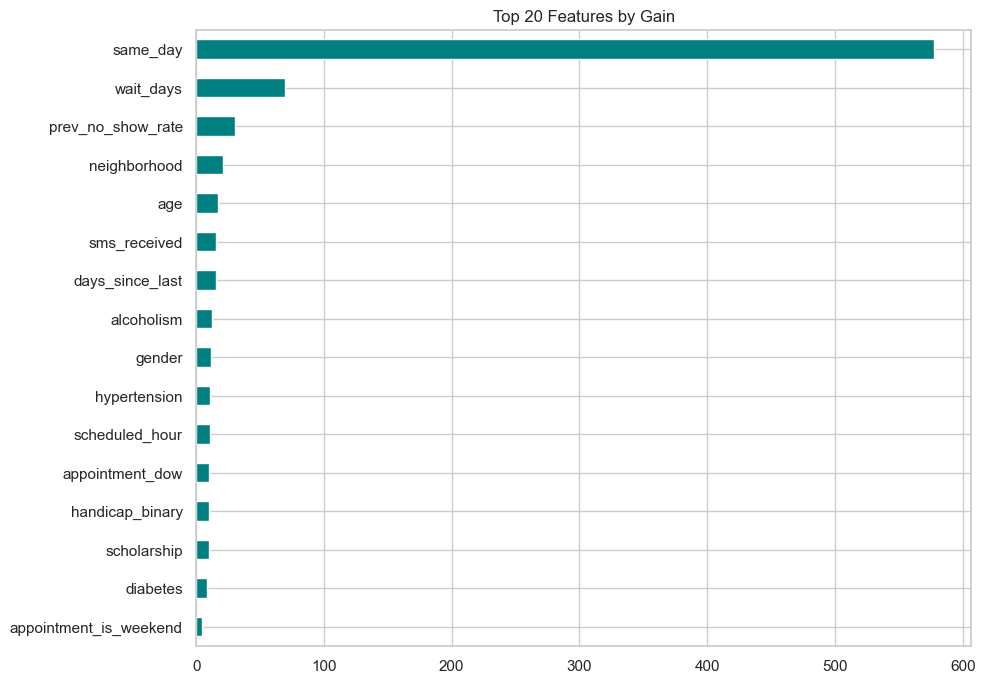

In [15]:
importances = pd.Series(
    bst.get_score(importance_type='gain'),
    index=X_train_tr.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Features by Gain')
plt.gca().invert_yaxis()
plt.show()

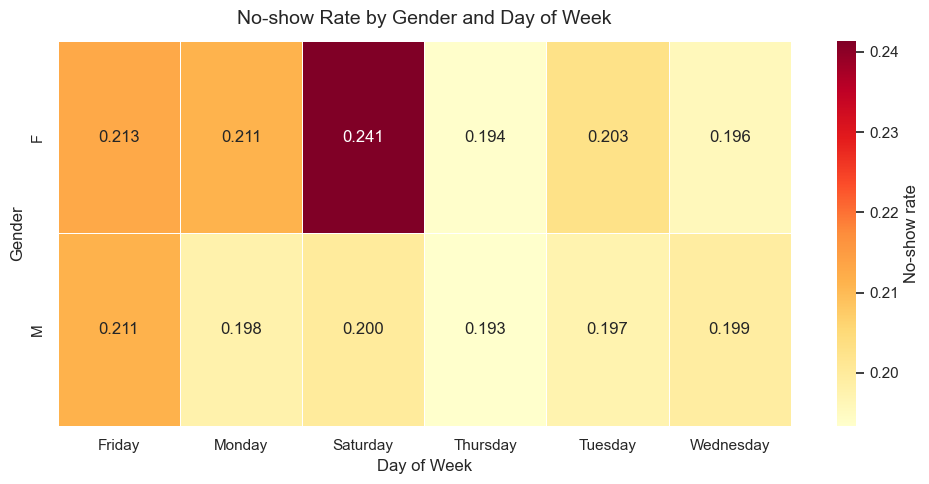

In [16]:
# No-show rate by Gender × Appointment Day of Week (heatmap style)
pivot_gender_dow = pd.pivot_table(
    df,
    values='target',
    index='gender',
    columns='appointment_dow',
    aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_gender_dow,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'No-show rate'}
)
plt.title('No-show Rate by Gender and Day of Week', fontsize=14, pad=12)
plt.xlabel('Day of Week')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

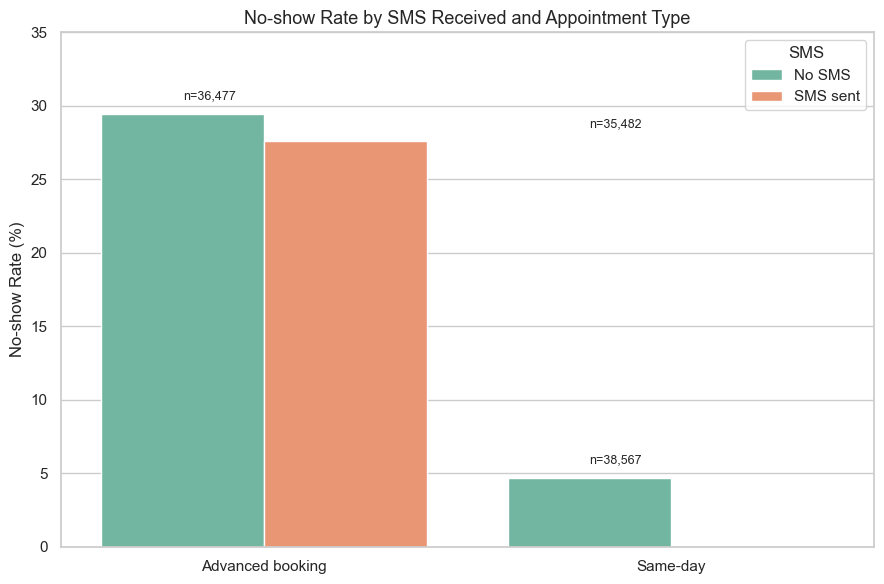

In [17]:
# No-show rate depending on SMS received and whether it's a same-day appointment
sms_same = df.groupby(['sms_received', 'same_day'])['target'].agg(['mean', 'count'])
sms_same['mean'] = sms_same['mean'] * 100  # to %

sms_same_reset = sms_same.reset_index()
sms_same_reset['sms_received'] = sms_same_reset['sms_received'].map({0: 'No SMS', 1: 'SMS sent'})
sms_same_reset['same_day'] = sms_same_reset['same_day'].map({0: 'Advanced booking', 1: 'Same-day'})

plt.figure(figsize=(9, 6))
sns.barplot(
    data=sms_same_reset,
    x='same_day',
    y='mean',
    hue='sms_received',
    palette='Set2'
)
plt.title('No-show Rate by SMS Received and Appointment Type', fontsize=13)
plt.ylabel('No-show Rate (%)')
plt.xlabel('')
plt.legend(title='SMS')
plt.ylim(0, 35)
for i, v in enumerate(sms_same_reset['count']):
    plt.text(i % 2 - 0.2 if i < 2 else i % 2 + 0.8,
             sms_same_reset['mean'].iloc[i] + 1,
             f'n={v:,}', fontsize=9)
plt.tight_layout()
plt.show()

/var/folders/vk/kp36p7g95xj99d7g2q4t3bmc0000gn/T/ipykernel_14213/3226159346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=neigh_stats.index, y=neigh_stats['no_show_rate']*100,


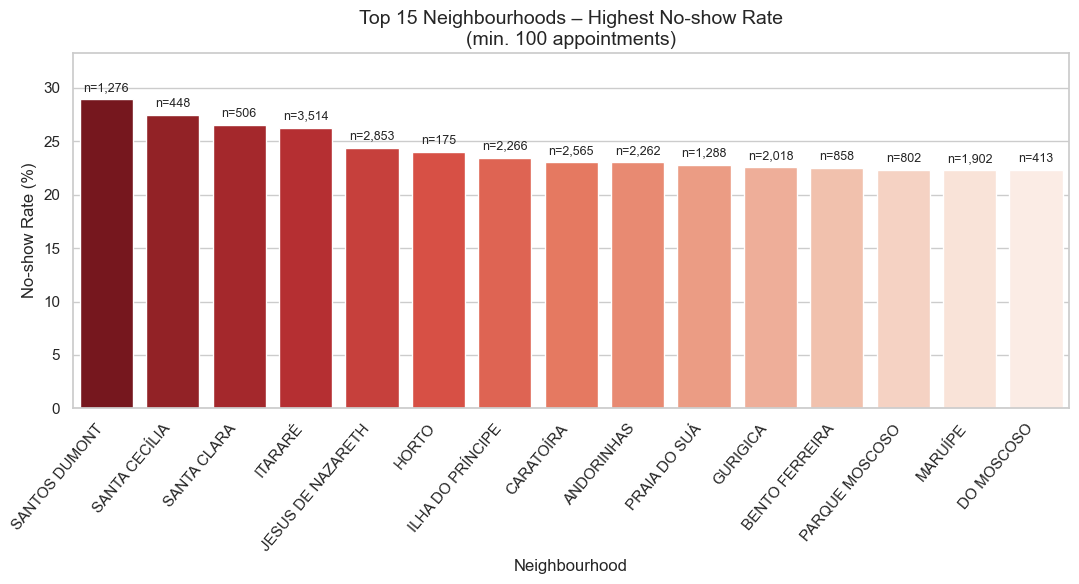

In [19]:
# Top 15 neighbourhoods with highest no-show rate (only those with enough data)
neigh_stats = df.groupby('neighborhood').agg(
    no_show_rate=('target', 'mean'),
    count=('target', 'size')
).sort_values('no_show_rate', ascending=False)

# Filter to places with at least 100 appointments
neigh_stats = neigh_stats[neigh_stats['count'] >= 100].head(15)

plt.figure(figsize=(11, 6))
bars = sns.barplot(x=neigh_stats.index, y=neigh_stats['no_show_rate']*100,
                   palette='Reds_r')

plt.title('Top 15 Neighbourhoods – Highest No-show Rate\n(min. 100 appointments)', fontsize=14)
plt.ylabel('No-show Rate (%)')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=50, ha='right')
plt.ylim(0, max(neigh_stats['no_show_rate']*100 * 1.15))

# Add count labels on bars
for bar, cnt in zip(bars.patches, neigh_stats['count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'n={cnt:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Wait days distribution (log scale to see long tail)
plt.figure(figsize=(11, 5))

# Only positive wait days
wait_positive = df[df['wait_days'] > 0]['wait_days']

sns.histplot(wait_positive, bins=80, log_scale=(False, True), color='teal', kde=True)
plt.title('Distribution of Waiting Days (positive values only, y-axis log)', fontsize=13)
plt.xlabel('Waiting days')
plt.ylabel('Count (log scale)')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [ ]:
# Binned previous no-show rate vs current no-show probability
df['prev_rate_bin'] = pd.cut(
    df['prev_no_show_rate'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=['0%', '1–20%', '21–40%', '41–60%', '61–80%', '81–100%']
)

prev_bin_rate = df.groupby('prev_rate_bin', observed=True)['target'].mean() * 100

plt.figure(figsize=(9, 6))
prev_bin_rate.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('No-show Rate by Binned Previous No-show Rate', fontsize=14)
plt.ylabel('Current No-show Rate (%)')
plt.xlabel('Previous No-show Rate')
plt.ylim(0, 60)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(prev_bin_rate):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()